In [1]:
# =============================================================================
# PHASE 1 — US DATA PIPELINE
# Macro-Market Regime Detection System
# =============================================================================
# Pulls all US market + macro series needed for regime detection, aligns them,
# and caches to local parquet files so you don't re-hit the APIs every run.
#
# Run this as cells in Jupyter / Colab — each "# %%" marks a new cell if your
# editor supports that convention (VS Code, Spyder). Otherwise just run top
# to bottom.
# =============================================================================

In [ ]:
# -----------------------------------------------------------------------------
# CELL 1 — Install dependencies (run once)
# -----------------------------------------------------------------------------
!pip install yfinance fredapi pandas pyarrow -q

In [2]:
# -----------------------------------------------------------------------------
# CELL 2 — Imports & config
# -----------------------------------------------------------------------------
import os
import time
import pandas as pd
import yfinance as yf
from fredapi import Fred

# ---- FRED API KEY ----------------------------------------------------------
# Get a free key here (takes ~2 min): https://fred.stlouisfed.org/docs/api/api_key.html
# Do NOT hardcode your key if you'll share this notebook publicly — use an
# environment variable instead. For quick local use, the hardcoded version
# is fine.

FRED_API_KEY = os.environ.get("FRED_API_KEY", "7c6d09837ad037551316d3aca89e820a")
fred = Fred(api_key=FRED_API_KEY)

# Date range — go back far enough to capture multiple regimes
# (dot-com bust, GFC, COVID crash, 2022 inflation shock)
START_DATE = "1999-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")

DATA_DIR = "data/raw"
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
# -----------------------------------------------------------------------------
# CELL 3 — Market data (Yahoo Finance via yfinance)
# -----------------------------------------------------------------------------
# S&P 500 (equity index) and VIX (volatility index)

MARKET_TICKERS = {
    "SP500": "^GSPC",
    "VIX": "^VIX",
}

def fetch_yfinance_series(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Fetch daily OHLCV data for a single ticker and return a clean DataFrame
    indexed by date with just the Close price (renamed to the ticker label)."""
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if df.empty:
        raise ValueError(f"No data returned for {ticker} — check the ticker symbol "
                          f"or your network connection.")
    # yfinance sometimes returns MultiIndex columns when multiple tickers are
    # requested at once — flatten just in case.
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    out = df[["Close"]].rename(columns={"Close": ticker})
    out.index.name = "date"
    return out

market_frames = {}
for label, ticker in MARKET_TICKERS.items():
    print(f"Fetching {label} ({ticker})...")
    market_frames[label] = fetch_yfinance_series(ticker, START_DATE, END_DATE)
    time.sleep(1)  # be polite to the API

market_df = pd.concat(market_frames.values(), axis=1)
market_df.columns = list(market_frames.keys())
market_df.to_parquet(f"{DATA_DIR}/us_market_raw.parquet")
print(market_df.tail())

Fetching SP500 (^GSPC)...
Fetching VIX (^VIX)...


C:\Users\ramee\AppData\Local\Temp\ipykernel_20108\2688355646.py:32: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  market_df = pd.concat(market_frames.values(), axis=1)


                  SP500        VIX
date                              
2026-06-23  7365.459961  19.490000
2026-06-24  7358.220215  18.629999
2026-06-25  7357.490234  18.889999
2026-06-26  7354.020020  18.410000
2026-06-29  7440.430176  17.650000


In [4]:
# -----------------------------------------------------------------------------
# CELL 4 — Macro data (FRED)
# -----------------------------------------------------------------------------
# Series chosen to cover: inflation, rates, yield curve, credit risk appetite,
# growth/activity proxy, and inflation expectations.

FRED_SERIES = {
    "CPI": "CPIAUCSL",          # Consumer Price Index (monthly, inflation level)
    "FEDFUNDS": "FEDFUNDS",     # Effective Federal Funds Rate (monthly, policy rate)
    "DGS10": "DGS10",           # 10-Year Treasury yield (daily)
    "DGS2": "DGS2",             # 2-Year Treasury yield (daily) — for curve slope
    "T5YIE": "T5YIE",           # 5-Year Breakeven Inflation Rate (daily, market-implied inflation)
    "BAA10Y": "BAA10Y",         # Moody's Baa Corporate Bond Yield minus 10Y Treasury
                                 # (credit risk appetite proxy — replaces BAMLH0A0HYM2,
                                 # which FRED now restricts to a rolling 3-year window
                                 # as of Apr 2026; full history is ICE-licensed/paid only)
    "INDPRO": "INDPRO",         # Industrial Production Index (monthly, growth/activity proxy — lagging)
    "PHILLY_FED": "GACDFSA066MSFRBPHI",  # Philadelphia Fed Manufacturing Index — Current General
                                 # Activity diffusion index (monthly, leading growth/sentiment proxy).
                                 # ISM PMI itself is NOT available free via API or FRED: ISM asked
                                 # FRED to remove all its series in 2016, and ISM data is now
                                 # licensed-only (Bloomberg/Moody's Analytics). The Philly Fed survey
                                 # is the standard free substitute — same diffusion-index logic as
                                 # ISM PMI, just centered at 0 instead of 50 (above 0 = expansion,
                                 # below 0 = contraction, vs. ISM's above/below 50).
}

def fetch_fred_series(series_id: str, start: str, end: str) -> pd.Series:
    """Fetch a single FRED series as a pandas Series indexed by date."""
    s = fred.get_series(series_id, observation_start=start, observation_end=end)
    s.index.name = "date"
    s.name = series_id
    return s

fred_frames = {}
for label, series_id in FRED_SERIES.items():
    print(f"Fetching {label} ({series_id})...")
    fred_frames[label] = fetch_fred_series(series_id, START_DATE, END_DATE)
    time.sleep(0.5)

fred_df = pd.concat(fred_frames.values(), axis=1)
fred_df.columns = list(fred_frames.keys())
fred_df.to_parquet(f"{DATA_DIR}/us_macro_raw.parquet")
print(fred_df.tail())

Fetching CPI (CPIAUCSL)...
Fetching FEDFUNDS (FEDFUNDS)...
Fetching DGS10 (DGS10)...
Fetching DGS2 (DGS2)...
Fetching T5YIE (T5YIE)...
Fetching BAA10Y (BAA10Y)...
Fetching INDPRO (INDPRO)...
Fetching PHILLY_FED (GACDFSA066MSFRBPHI)...
            CPI  FEDFUNDS  DGS10  DGS2  T5YIE  BAA10Y  INDPRO  PHILLY_FED
date                                                                     
2026-06-23  NaN       NaN   4.50  4.16   2.24    1.51     NaN         NaN
2026-06-24  NaN       NaN   4.41  4.11   2.19    1.52     NaN         NaN
2026-06-25  NaN       NaN   4.40  4.09   2.23    1.54     NaN         NaN
2026-06-26  NaN       NaN   4.38  4.07   2.21    1.56     NaN         NaN
2026-06-29  NaN       NaN    NaN   NaN   2.24     NaN     NaN         NaN


C:\Users\ramee\AppData\Local\Temp\ipykernel_20108\4171917943.py:41: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  fred_df = pd.concat(fred_frames.values(), axis=1)


In [6]:
# -----------------------------------------------------------------------------
# CELL 5 — Align to a common daily index
# -----------------------------------------------------------------------------
# Market data is daily (trading days only). Macro data is daily, monthly, or
# irregular (FEDFUNDS changes on FOMC dates, CPI is monthly).
#
# Approach: build a daily calendar from the market data's trading days, then
# forward-fill all macro series onto it. This is standard practice for this
# type of model — it reflects the fact that, e.g., last month's CPI reading
# remains "the known CPI" every day until the next release, rather than
# inventing values between releases.

daily_index = market_df.index

macro_daily = fred_df.reindex(
    pd.date_range(fred_df.index.min(), END_DATE, freq="D")
).ffill()
macro_daily.index.name = "date"

# Restrict macro data to the same trading-day calendar as the market data
macro_aligned = macro_daily.reindex(daily_index).ffill()

combined_df = market_df.join(macro_aligned, how="inner")
combined_df = combined_df.dropna(how="all")

print(f"Combined shape: {combined_df.shape}")
print(f"Date range: {combined_df.index.min()} to {combined_df.index.max()}")
print(combined_df.tail())

Combined shape: (6914, 10)
Date range: 1999-01-04 00:00:00 to 2026-06-29 00:00:00
                  SP500        VIX      CPI  FEDFUNDS  DGS10  DGS2  T5YIE  \
date                                                                        
2026-06-23  7365.459961  19.490000  333.979      3.63   4.50  4.16   2.24   
2026-06-24  7358.220215  18.629999  333.979      3.63   4.41  4.11   2.19   
2026-06-25  7357.490234  18.889999  333.979      3.63   4.40  4.09   2.23   
2026-06-26  7354.020020  18.410000  333.979      3.63   4.38  4.07   2.21   
2026-06-29  7440.430176  17.650000  333.979      3.63   4.38  4.07   2.24   

            BAA10Y    INDPRO  PHILLY_FED  
date                                      
2026-06-23    1.51  102.6475        10.3  
2026-06-24    1.52  102.6475        10.3  
2026-06-25    1.54  102.6475        10.3  
2026-06-26    1.56  102.6475        10.3  
2026-06-29    1.56  102.6475        10.3  


In [7]:
# -----------------------------------------------------------------------------
# CELL 6 — Sanity checks before saving
# -----------------------------------------------------------------------------
# Quick checks to catch obvious data issues before they propagate downstream.

print("Missing values per column:")
print(combined_df.isna().sum())

print("\nDate gaps check (should mostly be weekends/holidays):")
gaps = combined_df.index.to_series().diff().value_counts().head()
print(gaps)

print("\nValue ranges (sanity check against known history):")
print(combined_df.describe().T[["min", "max", "mean"]])

# Known reference points to eyeball:
# - SP500 should cross ~768 (Mar 2009 low) up to recent all-time highs
# - VIX should spike to ~80+ in 2008 and 2020
# - CPI should rise roughly monotonically (it's an index level, not %)
# - DGS10 should show 2020 lows near 0.5% and 2023 highs near 5%

Missing values per column:
SP500            1
VIX              0
CPI              0
FEDFUNDS         0
DGS10            0
DGS2             0
T5YIE         1004
BAA10Y           0
INDPRO           0
PHILLY_FED       0
dtype: int64

Date gaps check (should mostly be weekends/holidays):
date
1 days    5412
3 days    1249
4 days     182
2 days      67
5 days       2
Name: count, dtype: int64

Value ranges (sanity check against known history):
                   min          max         mean
SP500       676.530029  7609.779785  2318.880690
VIX           9.140000    82.690002    19.995755
CPI         164.700000   333.979000   232.770482
FEDFUNDS      0.050000     6.540000     2.143337
DGS10         0.520000     6.790000     3.423491
DGS2          0.090000     6.930000     2.401147
T5YIE        -2.240000     3.590000     1.963526
BAA10Y        1.360000     6.160000     2.448865
INDPRO       84.561900   104.100400    97.033908
PHILLY_FED  -58.700000    48.800000     7.206465


In [8]:
# -----------------------------------------------------------------------------
# CELL 7 — Save final cleaned dataset
# -----------------------------------------------------------------------------
PROCESSED_DIR = "data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

combined_df.to_parquet(f"{PROCESSED_DIR}/us_combined_daily.parquet")
combined_df.to_csv(f"{PROCESSED_DIR}/us_combined_daily.csv")  # CSV copy for easy inspection

print(f"Saved {combined_df.shape[0]} rows x {combined_df.shape[1]} columns to "
      f"{PROCESSED_DIR}/us_combined_daily.parquet")

Saved 6914 rows x 10 columns to data/processed/us_combined_daily.parquet


Matplotlib is building the font cache; this may take a moment.


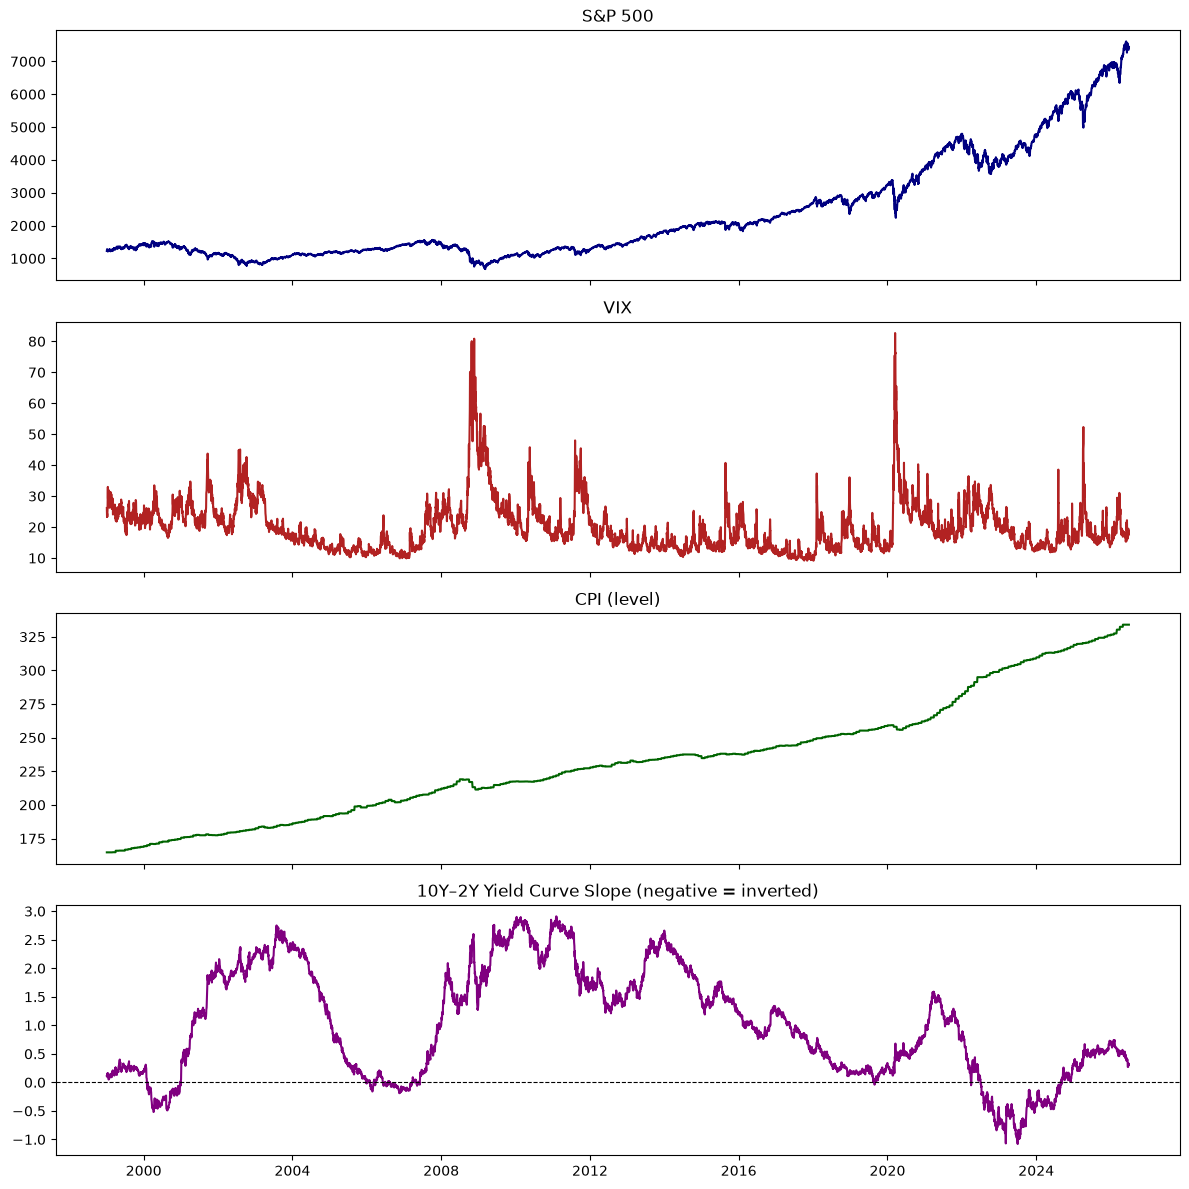

If these four charts roughly match what you'd expect from financial history (2008 VIX spike, 2020 crash, 2022-23 curve inversion), Phase 1 is done — move to feature engineering (Phase 2).


In [9]:
# -----------------------------------------------------------------------------
# CELL 8 — Quick visual sanity plot (optional but recommended)
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(combined_df.index, combined_df["SP500"], color="navy")
axes[0].set_title("S&P 500")

axes[1].plot(combined_df.index, combined_df["VIX"], color="firebrick")
axes[1].set_title("VIX")

axes[2].plot(combined_df.index, combined_df["CPI"], color="darkgreen")
axes[2].set_title("CPI (level)")

axes[3].plot(combined_df.index, combined_df["DGS10"] - combined_df["DGS2"], color="purple")
axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[3].set_title("10Y–2Y Yield Curve Slope (negative = inverted)")

plt.tight_layout()
plt.savefig("data/processed/sanity_check_plots.png", dpi=120)
plt.show()

print("If these four charts roughly match what you'd expect from financial "
      "history (2008 VIX spike, 2020 crash, 2022-23 curve inversion), "
      "Phase 1 is done — move to feature engineering (Phase 2).")